In [1]:
# baca file
library(readxl)
library(dplyr)

data_all <- read_excel("/Users/ansyaku/jupy/cpi_exa_bi_rate.xls")

# filter mulai 2005-M07
data <- data_all %>%
  filter(date >= "2005-M07")

head(data)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




date,cpi_ino,cpi_us,cpi_sin,exa_ino,exa_sin,bi_rate_ino
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2005-M07,41.41564,89.61021,65.992,9798.5,1.68212,8.50
2005-M08,41.64412,90.06881,66.304,9966.3,1.66250,8.75
2005-M09,41.92845,91.16945,66.397,10218.8,1.68080,10.00
2005-M10,45.57904,91.35289,66.668,10090.0,1.69080,11.00
2005-M11,46.17816,90.61913,66.587,10067.5,1.69935,12.25
2005-M12,46.15785,90.25225,66.609,9841.3,1.67429,12.75


In [2]:
data$log_cpi_ino     <- log(data$cpi_ino)
data$log_cpi_us      <- log(data$cpi_us)
data$log_cpi_sin     <- log(data$cpi_sin)
data$log_exa_ino     <- log(data$exa_ino)
data$log_exa_sin     <- log(data$exa_sin)
data$log_bi_rate_ino <- log(data$bi_rate_ino)

head(data[, c("date",
  "log_cpi_ino",  "log_cpi_us",
  "log_cpi_sin",  "log_exa_ino",
  "log_exa_sin",  "log_bi_rate_ino"
)])

date,log_cpi_ino,log_cpi_us,log_cpi_sin,log_exa_ino,log_exa_sin,log_bi_rate_ino
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2005-M07,3.723659,4.495469,4.189534,9.189985,0.5200549,2.140066
2005-M08,3.729160,4.500574,4.194250,9.206965,0.5083225,2.169054
2005-M09,3.735965,4.512720,4.195652,9.231984,0.5192699,2.302585
2005-M10,3.819448,4.514730,4.199725,9.219300,0.5252018,2.397895
2005-M11,3.832507,4.506665,4.198509,9.217068,0.5302458,2.505526
2005-M12,3.832067,4.502609,4.198840,9.194343,0.5153892,2.545531


In [3]:
data$SGDIDR <- data$exa_ino/data$exa_sin
data$log_SGDIDR <- log(data$SGDIDR)
data$log_RER <- data$log_SGDIDR + data$log_cpi_sin - data$log_cpi_ino

head(data[,c("date",
  "log_cpi_ino",  "log_cpi_us",
  "log_cpi_sin",  "log_exa_ino",
  "log_exa_sin",  "log_bi_rate_ino", "log_SGDIDR","log_RER"
)])

date,log_cpi_ino,log_cpi_us,log_cpi_sin,log_exa_ino,log_exa_sin,log_bi_rate_ino,log_SGDIDR,log_RER
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2005-M07,3.723659,4.495469,4.189534,9.189985,0.5200549,2.140066,8.669930,9.135805
2005-M08,3.729160,4.500574,4.194250,9.206965,0.5083225,2.169054,8.698642,9.163732
2005-M09,3.735965,4.512720,4.195652,9.231984,0.5192699,2.302585,8.712715,9.172402
2005-M10,3.819448,4.514730,4.199725,9.219300,0.5252018,2.397895,8.694098,9.074375
2005-M11,3.832507,4.506665,4.198509,9.217068,0.5302458,2.505526,8.686822,9.052824
2005-M12,3.832067,4.502609,4.198840,9.194343,0.5153892,2.545531,8.678954,9.045727


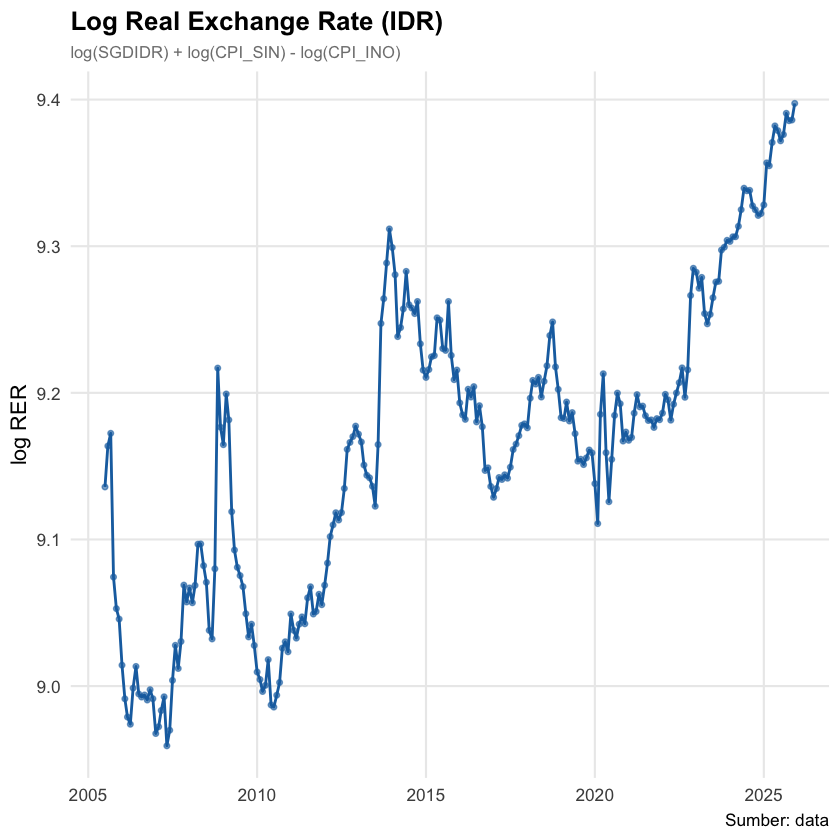

In [4]:
library(ggplot2)
library(dplyr)

# Pastikan kolom date diparse dengan benar
data <- data %>%
  mutate(date_parsed = as.Date(paste0(date, "-01"), format = "%Y-M%m-%d"))

# Line chart log_RER
ggplot(data, aes(x = date_parsed, y = log_RER)) +
  geom_line(color = "#1a6faf", linewidth = 0.8) +
  geom_point(color = "#1a6faf", size = 1.2, alpha = 0.6) +
  labs(
    title = "Log Real Exchange Rate (IDR)",
    subtitle = "log(SGDIDR) + log(CPI_SIN) - log(CPI_INO)",
    x = NULL,
    y = "log RER",
    caption = "Sumber: data"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold"),
    plot.subtitle = element_text(color = "gray50", size = 10),
    panel.grid.minor = element_blank()
  )

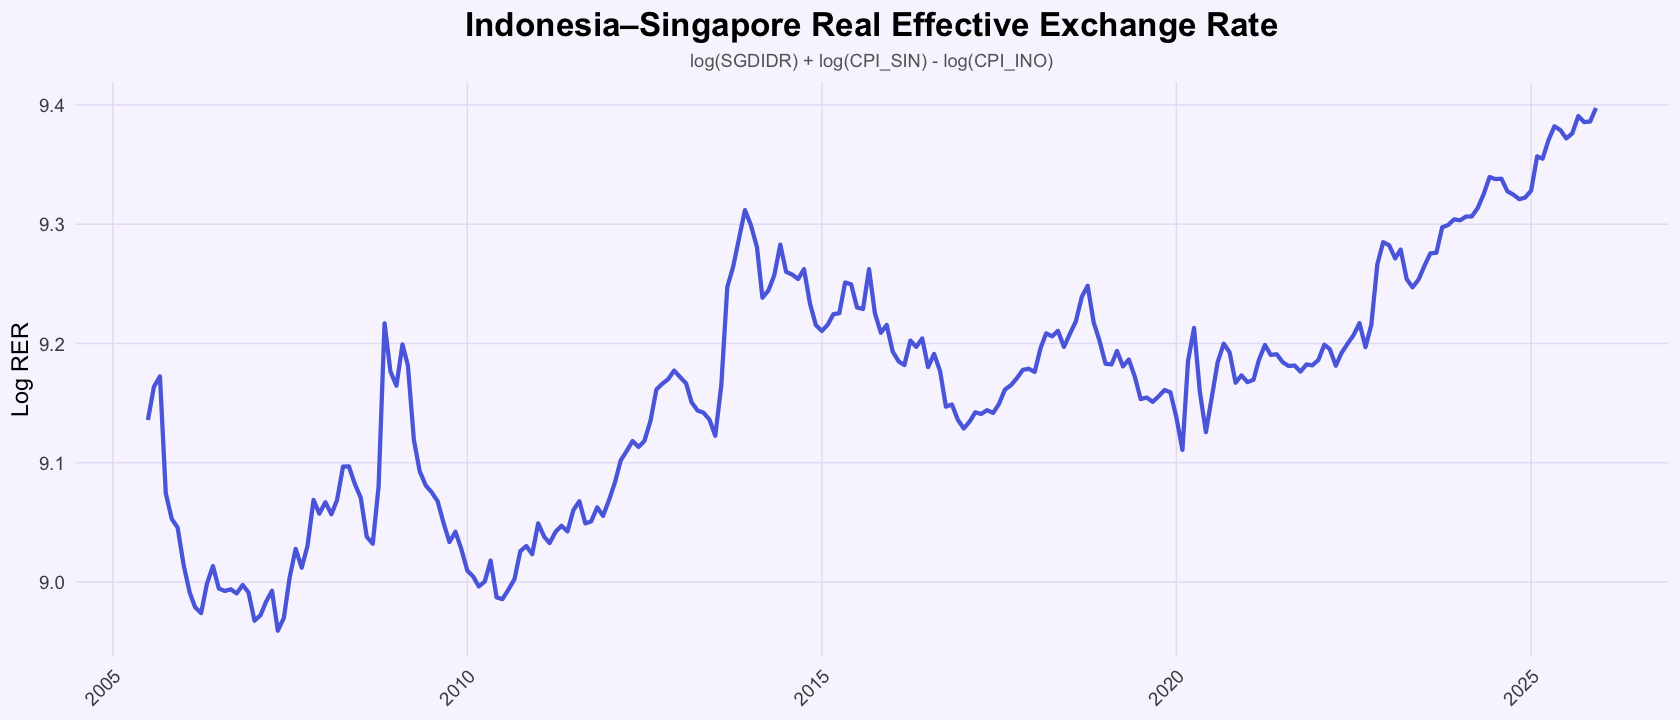

In [5]:
options(repr.plot.width = 14, repr.plot.height = 6)

ggplot(data, aes(x = date_parsed, y = log_RER)) +
  
  geom_line(
    color = "#5b6ee1",
    linewidth = 1.2
  ) +
  
  labs(
    title = "Indonesia–Singapore Real Effective Exchange Rate",
    subtitle = "log(SGDIDR) + log(CPI_SIN) - log(CPI_INO)",
    x = NULL,
    y = "Log RER"
  ) +
  
  theme_minimal(base_size = 14) +
  
  theme(
    
    # background pastel
    plot.background = element_rect(
      fill = "#f8f6ff",
      color = NA
    ),
    
    panel.background = element_rect(
      fill = "#f8f6ff",
      color = NA
    ),
    
    # title center
    plot.title = element_text(
      face = "bold",
      size = 20,
      hjust = 0.5
    ),
    
    plot.subtitle = element_text(
      size = 11,
      color = "gray40",
      hjust = 0.5
    ),
    
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    ),
    
    panel.grid.minor = element_blank(),
    
    panel.grid.major = element_line(
      color = "#e6e1f5",
      linewidth = 0.4
    )
  )

In [6]:
library(mFilter)
library(tidyverse)

# Konstruksi log_RER
data <- data %>%
  mutate(log_RER = log_SGDIDR + log_cpi_sin - log_cpi_ino)

# Aplikasi HP Filter
hp_result <- hpfilter(data$log_RER, freq = 14400, type = "lambda")

# Ekstrak komponen + misalignment sekaligus
data <- data %>%
  mutate(
    RER_equilibrium  = as.numeric(hp_result$trend),
    misalignment     = as.numeric(hp_result$cycle),
    misalignment_pct = (exp(misalignment) - 1) * 100
  )

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
✔ readr     2.2.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


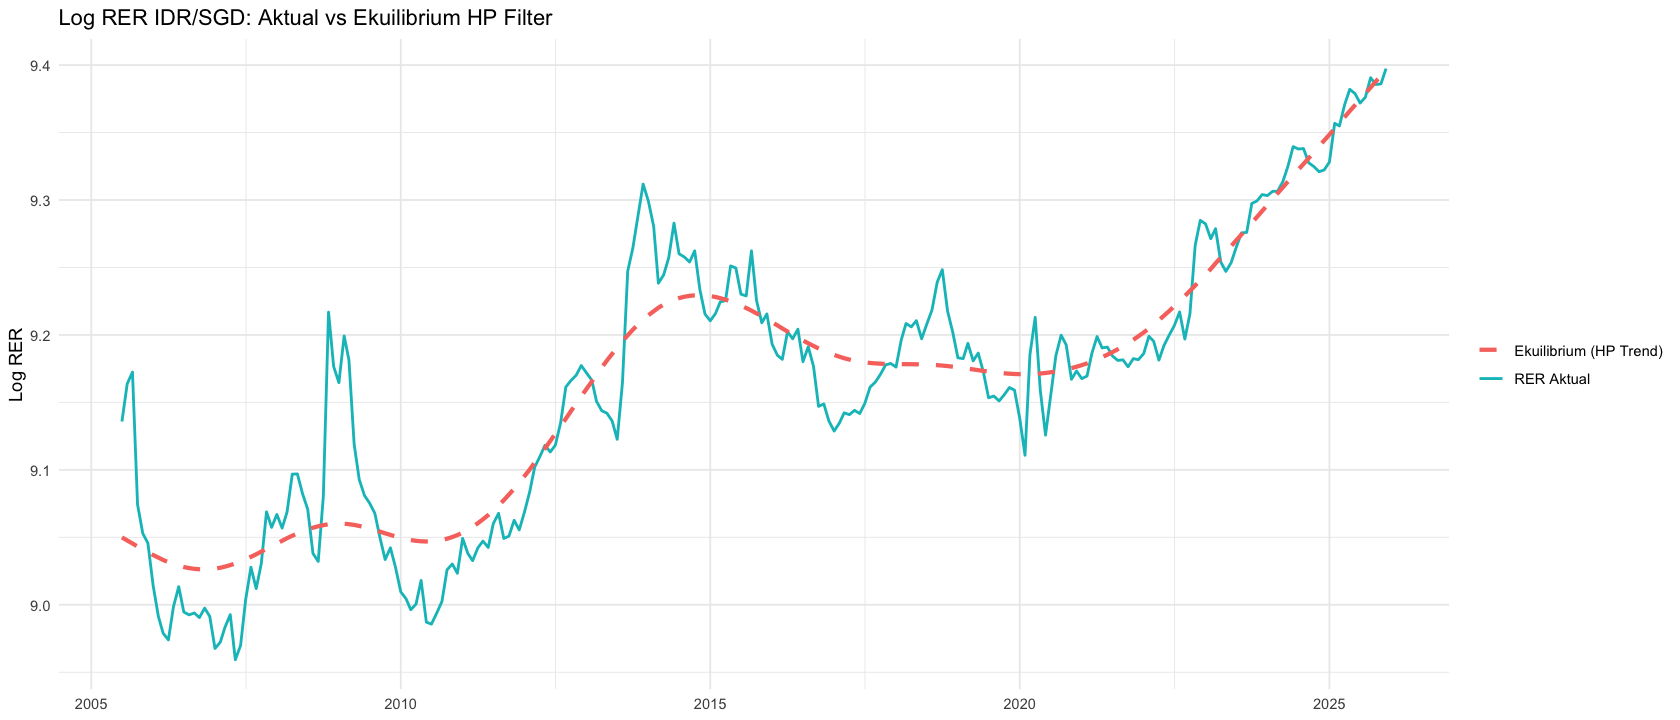

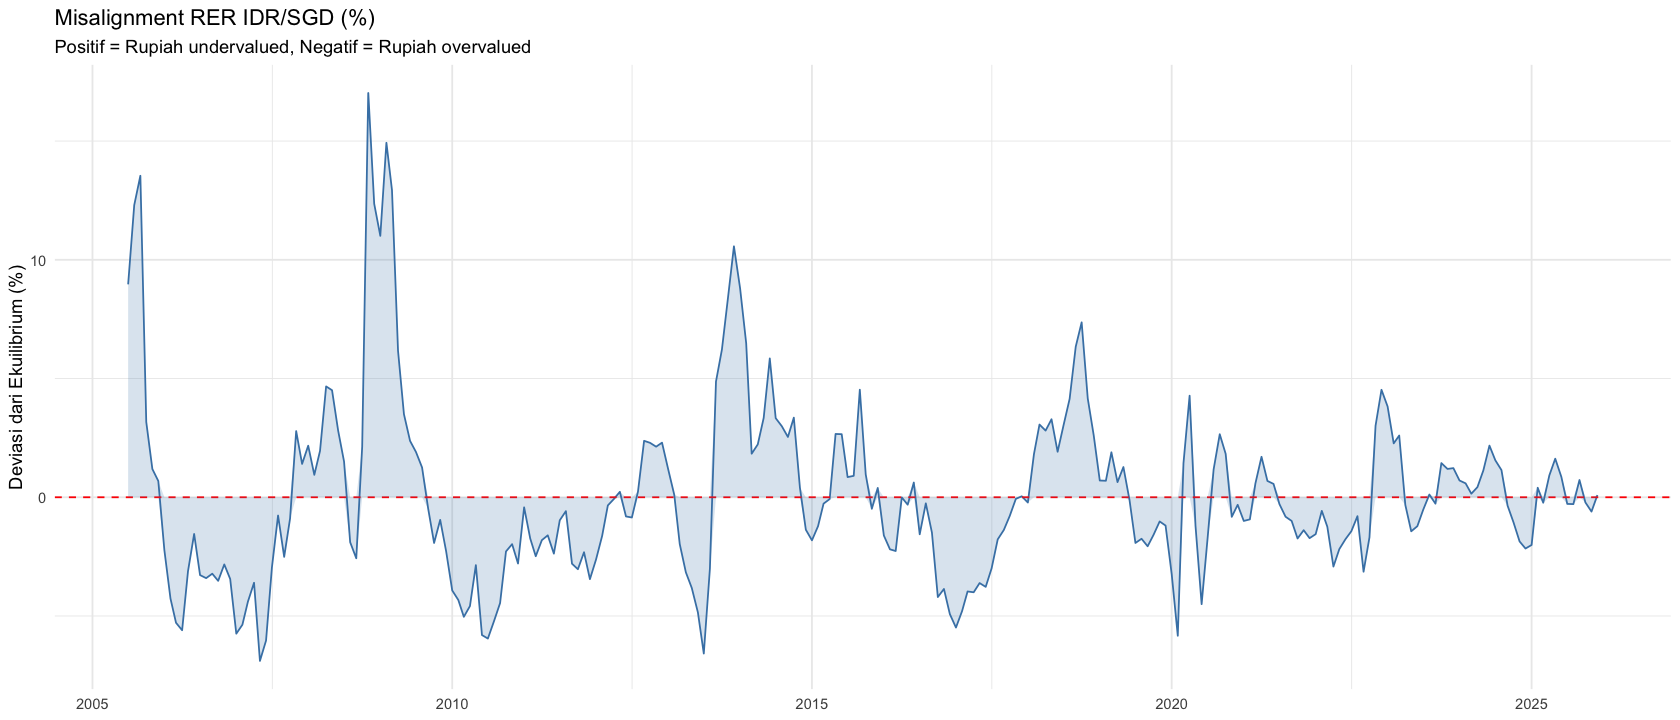

In [7]:
# Plot 1
ggplot(data, aes(x = date_parsed)) +
  geom_line(aes(y = log_RER, color = "RER Aktual"), linewidth = 0.8) +
  geom_line(aes(y = RER_equilibrium, color = "Ekuilibrium (HP Trend)"),
            linewidth = 1.2, linetype = "dashed") +
  labs(title = "Log RER IDR/SGD: Aktual vs Ekuilibrium HP Filter",
       y = "Log RER", x = NULL, color = NULL) +
  theme_minimal()

# Plot 2
ggplot(data, aes(x = date_parsed, y = misalignment_pct)) +
  geom_line(color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  geom_ribbon(aes(ymin = pmin(misalignment_pct, 0),
                  ymax = pmax(misalignment_pct, 0)),
              alpha = 0.2, fill = "steelblue") +
  labs(title = "Misalignment RER IDR/SGD (%)",
       subtitle = "Positif = Rupiah undervalued, Negatif = Rupiah overvalued",
       y = "Deviasi dari Ekuilibrium (%)", x = NULL) +
  theme_minimal()

In [8]:
summary_misalignment <- data %>%
  summarise(
    mean_pct   = mean(misalignment_pct, na.rm = TRUE),
    sd_pct     = sd(misalignment_pct, na.rm = TRUE),
    max_over   = max(misalignment_pct, na.rm = TRUE),   # overvalued terbesar
    max_under  = min(misalignment_pct, na.rm = TRUE),   # undervalued terbesar
    pct_over   = mean(misalignment_pct > 0) * 100,      # % waktu overvalued
    pct_under  = mean(misalignment_pct < 0) * 100       # % waktu undervalued
  )
summary_misalignment

mean_pct,sd_pct,max_over,max_under,pct_over,pct_under
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.06802977,3.758263,17.02426,-6.891868,43.08943,56.91057


In [9]:
library(urca)

# ── Fungsi helper untuk ekstrak hasil ur.df ───────────────────────────────────
run_adf <- function(x, varname, type = "drift", lags = "AIC") {
  res <- ur.df(x, type = type, selectlags = lags)
  tau <- res@teststat[1]          # t-statistic
  cv  <- res@cval[1, ]            # critical values 1%, 5%, 10%
  cat(sprintf("\n%s | type=%s\n", varname, type))
  cat(sprintf("  tau = %.4f\n", tau))
  cat(sprintf("  CV  1%%=%.4f  5%%=%.4f  10%%=%.4f\n", cv[1], cv[2], cv[3]))
  cat(sprintf("  Stasioner? %s\n",
      ifelse(tau < cv[2], "YA (tolak H0)", "TIDAK (gagal tolak H0)")))
  return(list(tau = tau, cv = cv))
}

# ── Level ─────────────────────────────────────────────────────────────────────
cat("============================================================\n")
cat("UNIT ROOT TEST — LEVEL\n")
cat("============================================================\n")
r1 <- run_adf(data$log_SGDIDR,  "log_SGDIDR",  type = "drift")
r2 <- run_adf(data$log_cpi_ino, "log_cpi_ino", type = "trend")
r3 <- run_adf(data$log_cpi_sin, "log_cpi_sin", type = "trend")

# ── First Difference ──────────────────────────────────────────────────────────
cat("\n============================================================\n")
cat("UNIT ROOT TEST — FIRST DIFFERENCE\n")
cat("============================================================\n")
r4 <- run_adf(diff(data$log_SGDIDR),  "D.log_SGDIDR",  type = "drift")
r5 <- run_adf(diff(data$log_cpi_ino), "D.log_cpi_ino", type = "drift")
r6 <- run_adf(diff(data$log_cpi_sin), "D.log_cpi_sin", type = "drift")

# ── Tabel ringkasan untuk paper ───────────────────────────────────────────────
cat("\n============================================================\n")
cat("TABEL RINGKASAN — untuk dilaporkan di paper\n")
cat("============================================================\n")

summary_table <- data.frame(
  Variabel = c("log_SGDIDR", "log_cpi_ino", "log_cpi_sin"),
  
  # Level
  tau_level = c(r1$tau, r2$tau, r3$tau),
  cv5_level = c(r1$cv[2], r2$cv[2], r3$cv[2]),
  stat_level = ifelse(
    c(r1$tau, r2$tau, r3$tau) < c(r1$cv[2], r2$cv[2], r3$cv[2]),
    "I(0)", "non-stasioner"
  ),
  
  # First difference
  tau_diff = c(r4$tau, r5$tau, r6$tau),
  cv5_diff = c(r4$cv[2], r5$cv[2], r6$cv[2]),
  stat_diff = ifelse(
    c(r4$tau, r5$tau, r6$tau) < c(r4$cv[2], r5$cv[2], r6$cv[2]),
    "I(0)", "non-stasioner"
  ),
  
  Kesimpulan = NA
)

# Kesimpulan orde integrasi
summary_table$Kesimpulan <- ifelse(
  summary_table$stat_level == "non-stasioner" &
  summary_table$stat_diff  == "I(0)",
  "I(1) ✅", "Perlu cek lanjut"
)

print(summary_table)

UNIT ROOT TEST — LEVEL

log_SGDIDR | type=drift
  tau = -0.7312
  CV  1%=-3.4600  5%=-2.8800  10%=-2.5700
  Stasioner? TIDAK (gagal tolak H0)

log_cpi_ino | type=trend
  tau = -3.2911
  CV  1%=-3.9900  5%=-3.4300  10%=-3.1300
  Stasioner? TIDAK (gagal tolak H0)

log_cpi_sin | type=trend
  tau = -1.1457
  CV  1%=-3.9900  5%=-3.4300  10%=-3.1300
  Stasioner? TIDAK (gagal tolak H0)

UNIT ROOT TEST — FIRST DIFFERENCE

D.log_SGDIDR | type=drift
  tau = -12.5020
  CV  1%=-3.4600  5%=-2.8800  10%=-2.5700
  Stasioner? YA (tolak H0)

D.log_cpi_ino | type=drift
  tau = -10.6133
  CV  1%=-3.4600  5%=-2.8800  10%=-2.5700
  Stasioner? YA (tolak H0)

D.log_cpi_sin | type=drift
  tau = -12.6957
  CV  1%=-3.4600  5%=-2.8800  10%=-2.5700
  Stasioner? YA (tolak H0)

TABEL RINGKASAN — untuk dilaporkan di paper
     Variabel  tau_level cv5_level    stat_level  tau_diff cv5_diff stat_diff
1  log_SGDIDR -0.7312323     -2.88 non-stasioner -12.50195    -2.88      I(0)
2 log_cpi_ino -3.2911212     -3.43 non-st


Call:
lm(formula = log_SGDIDR ~ log_cpi_ino + log_cpi_sin, data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.10384 -0.03197 -0.00135  0.03075  0.16327 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.97936    0.24363  20.439   <2e-16 ***
log_cpi_ino  0.85191    0.04170  20.427   <2e-16 ***
log_cpi_sin  0.09233    0.09295   0.993    0.322    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.0503 on 243 degrees of freedom
Multiple R-squared:  0.9561,	Adjusted R-squared:  0.9557 
F-statistic:  2645 on 2 and 243 DF,  p-value: < 2.2e-16



Persamaan kointegrasi:
ln(SGDIDR) = 4.9794 + 0.8519*ln(CPI_INO) + 0.0923*ln(CPI_SIN)

=== ADF pada Residual ===
tau    = -4.5645
CV 1%  = -2.5800
CV 5%  = -1.9500
CV 10% = -1.6200
Kointegrasi? YA — residual I(0), variabel terkointegrasi

=== Uji Restriksi PPP Ketat ===
beta1 = 0.8519 | H0: beta1=-1 | t=44.4051 | p=0.0000 | Tolak H0
beta2 = 0.0923 | H0: beta2=+1 | t=-9.7656 | p=0.0000 | Tolak H0


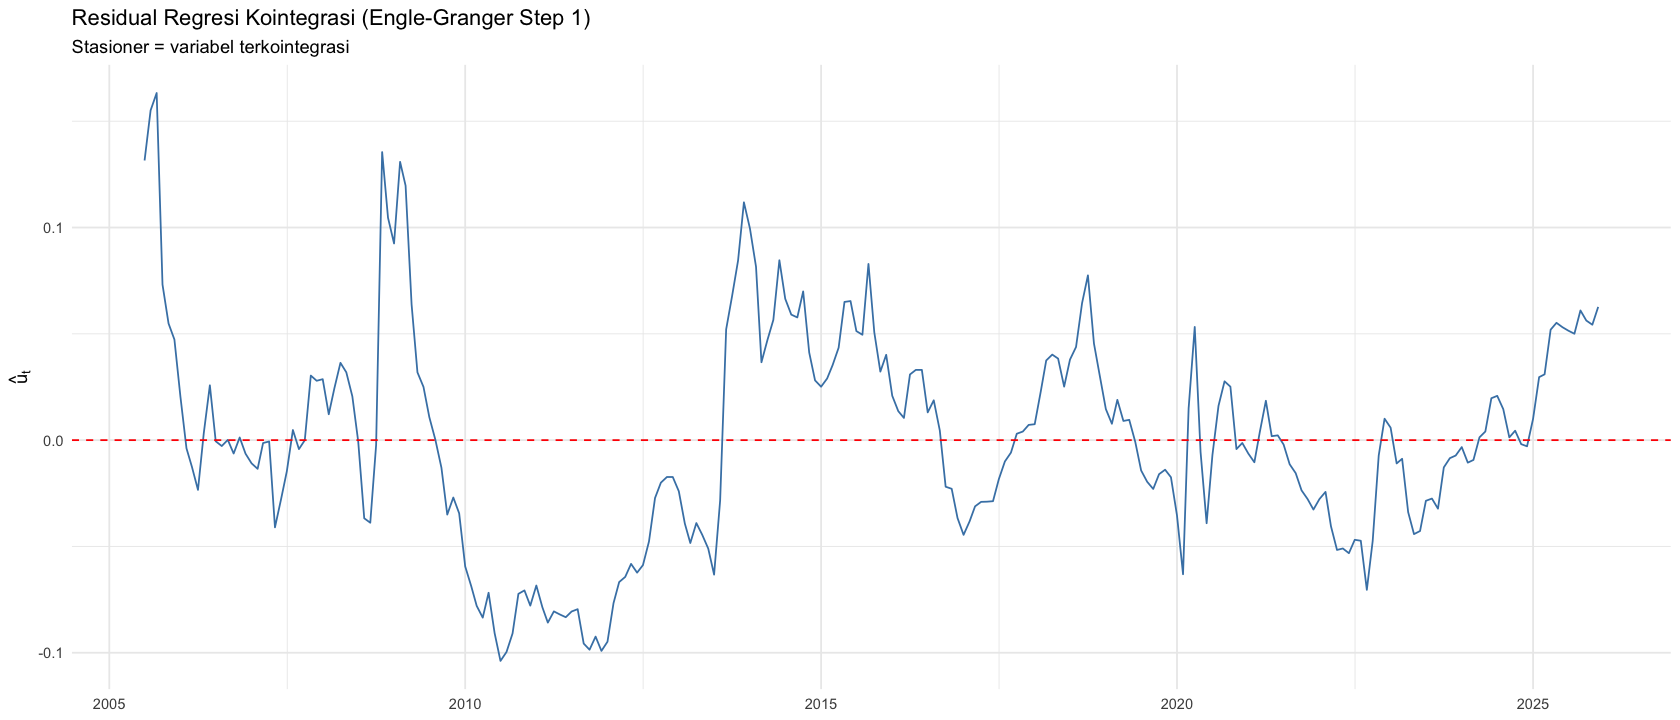

In [12]:
# ── Engle-Granger Two-Step ────────────────────────────────────────────────────
library(urca)
library(ggplot2)

# Step 1: Regresi kointegrasi
eg_model <- lm(log_SGDIDR ~ log_cpi_ino + log_cpi_sin, data = data)
summary(eg_model)

# Ekstrak koefisien
alpha <- coef(eg_model)[1]
beta1 <- coef(eg_model)[2]
beta2 <- coef(eg_model)[3]

cat(sprintf("\nPersamaan kointegrasi:\n"))
cat(sprintf("ln(SGDIDR) = %.4f + %.4f*ln(CPI_INO) + %.4f*ln(CPI_SIN)\n",
            alpha, beta1, beta2))

# Step 2: Uji stasioneritas residual
resid_eg  <- residuals(eg_model)
adf_resid <- ur.df(resid_eg, type = "none", selectlags = "AIC")

tau_resid <- adf_resid@teststat[1]
cv_resid  <- adf_resid@cval[1, ]

cat("\n=== ADF pada Residual ===\n")
cat(sprintf("tau    = %.4f\n", tau_resid))
cat(sprintf("CV 1%%  = %.4f\n", cv_resid[1]))
cat(sprintf("CV 5%%  = %.4f\n", cv_resid[2]))
cat(sprintf("CV 10%% = %.4f\n", cv_resid[3]))
cat(sprintf("Kointegrasi? %s\n",
    ifelse(tau_resid < cv_resid[2],
           "YA — residual I(0), variabel terkointegrasi",
           "TIDAK — residual non-stasioner")))

# ── Uji PPP ketat tanpa package car ──────────────────────────────────────────
t_beta1 <- (coef(eg_model)[2] - (-1)) / sqrt(vcov(eg_model)[2,2])
p_beta1 <- 2 * pt(abs(t_beta1), df = nrow(data) - 3, lower.tail = FALSE)

t_beta2 <- (coef(eg_model)[3] - 1) / sqrt(vcov(eg_model)[3,3])
p_beta2 <- 2 * pt(abs(t_beta2), df = nrow(data) - 3, lower.tail = FALSE)

cat("\n=== Uji Restriksi PPP Ketat ===\n")
cat(sprintf("beta1 = %.4f | H0: beta1=-1 | t=%.4f | p=%.4f | %s\n",
            beta1, t_beta1, p_beta1,
            ifelse(p_beta1 < 0.05, "Tolak H0", "Gagal tolak H0")))
cat(sprintf("beta2 = %.4f | H0: beta2=+1 | t=%.4f | p=%.4f | %s\n",
            beta2, t_beta2, p_beta2,
            ifelse(p_beta2 < 0.05, "Tolak H0", "Gagal tolak H0")))

# ── Plot residual ─────────────────────────────────────────────────────────────
data$resid_eg <- resid_eg

ggplot(data, aes(x = date_parsed, y = resid_eg)) +
  geom_line(color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  labs(title = "Residual Regresi Kointegrasi (Engle-Granger Step 1)",
       subtitle = "Stasioner = variabel terkointegrasi",
       y = expression(hat(u)[t]), x = NULL) +
  theme_minimal()

In [14]:
library(urca)
library(vars)

# Buat matrix dengan nama kolom yang jelas
rer_mat <- cbind(
  log_SGDIDR  = data$log_SGDIDR,
  log_cpi_ino = data$log_cpi_ino,
  log_cpi_sin = data$log_cpi_sin
)

# Lag selection
var_select <- VARselect(rer_mat, lag.max = 12, type = "const")
cat("=== Lag Selection ===\n")
print(var_select$selection)

lag_opt <- var_select$selection["AIC(n)"]
cat(sprintf("\nLag optimal (AIC): %d\n", lag_opt))

# Johansen trace test
jo_trace <- ca.jo(
  rer_mat,
  type  = "trace",
  ecdet = "const",
  K     = lag_opt
)
summary(jo_trace)

# Johansen max eigenvalue test
jo_eigen <- ca.jo(
  rer_mat,
  type  = "eigen",
  ecdet = "const",
  K     = lag_opt
)
summary(jo_eigen)

=== Lag Selection ===
AIC(n)  HQ(n)  SC(n) FPE(n) 
     7      4      4      7 

Lag optimal (AIC): 7



###################### 
# Johansen-Procedure # 
###################### 

Test type: trace statistic , without linear trend and constant in cointegration 

Eigenvalues (lambda):
[1]  1.484362e-01  6.825333e-02  1.829143e-02 -1.652905e-16

Values of teststatistic and critical values of test:

          test 10pct  5pct  1pct
r <= 2 |  4.41  7.52  9.24 12.97
r <= 1 | 21.31 17.85 19.96 24.60
r = 0  | 59.71 32.00 34.91 41.07

Eigenvectors, normalised to first column:
(These are the cointegration relations)

               log_SGDIDR.l7 log_cpi_ino.l7 log_cpi_sin.l7   constant
log_SGDIDR.l7      1.0000000      1.0000000       1.000000  1.0000000
log_cpi_ino.l7    -1.2951155     -0.8228620      -4.912232 -0.1053672
log_cpi_sin.l7     0.2306617     -0.1885605       9.395985 -0.3028647
constant          -4.3008865     -4.7096525     -29.235582 -7.2411054

Weights W:
(This is the loading matrix)

              log_SGDIDR.l7 log_cpi_ino.l7 log_cpi_sin.l7      constant
log_SGDIDR.d   -0.018081753


###################### 
# Johansen-Procedure # 
###################### 

Test type: maximal eigenvalue statistic (lambda max) , without linear trend and constant in cointegration 

Eigenvalues (lambda):
[1]  1.484362e-01  6.825333e-02  1.829143e-02 -1.652905e-16

Values of teststatistic and critical values of test:

          test 10pct  5pct  1pct
r <= 2 |  4.41  7.52  9.24 12.97
r <= 1 | 16.90 13.75 15.67 20.20
r = 0  | 38.40 19.77 22.00 26.81

Eigenvectors, normalised to first column:
(These are the cointegration relations)

               log_SGDIDR.l7 log_cpi_ino.l7 log_cpi_sin.l7   constant
log_SGDIDR.l7      1.0000000      1.0000000       1.000000  1.0000000
log_cpi_ino.l7    -1.2951155     -0.8228620      -4.912232 -0.1053672
log_cpi_sin.l7     0.2306617     -0.1885605       9.395985 -0.3028647
constant          -4.3008865     -4.7096525     -29.235582 -7.2411054

Weights W:
(This is the loading matrix)

              log_SGDIDR.l7 log_cpi_ino.l7 log_cpi_sin.l7      constant
l